# Fraud Shield - Exploratory Data Analysis

Goal: understand class balance, feature distributions, and fraud patterns
in the Kaggle credit card transactions dataset before feature engineering.

**Inputs:** `data/raw/fraudTrain.csv`, `data/raw/fraudTest.csv`


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.features.engineering import add_category_amt_zscore

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

import sys, os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

## 1. Load data


In [3]:
train = pd.read_csv('../data/raw/fraudTrain.csv')
test = pd.read_csv('../data/raw/fraudTest.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()


Train shape: (1296675, 23)
Test shape:  (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## 2. Missing values


In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:' if len(missing) else 'No missing values found.')
missing


No missing values found.


Series([], dtype: int64)

## 3. Class balance

`is_fraud` is expected to be heavily imbalanced -- this drives the
SMOTE/undersampling/class-weighting decision in the next notebook.


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

is_fraud
0    99.4211
1     0.5789
Name: proportion, dtype: float64


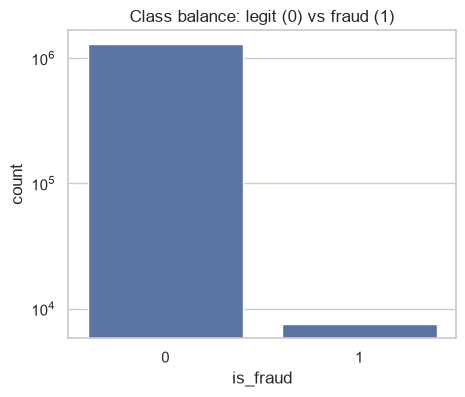

In [6]:
fraud_counts = train['is_fraud'].value_counts()
fraud_pct = train['is_fraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='is_fraud', data=train, ax=ax)
ax.set_title('Class balance: legit (0) vs fraud (1)')
ax.set_yscale('log')
plt.show()


## 4. Transaction amount (`amt`)

Compare the distribution of transaction amounts for legit vs fraudulent
transactions -- fraud is often associated with unusual amount patterns.


              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


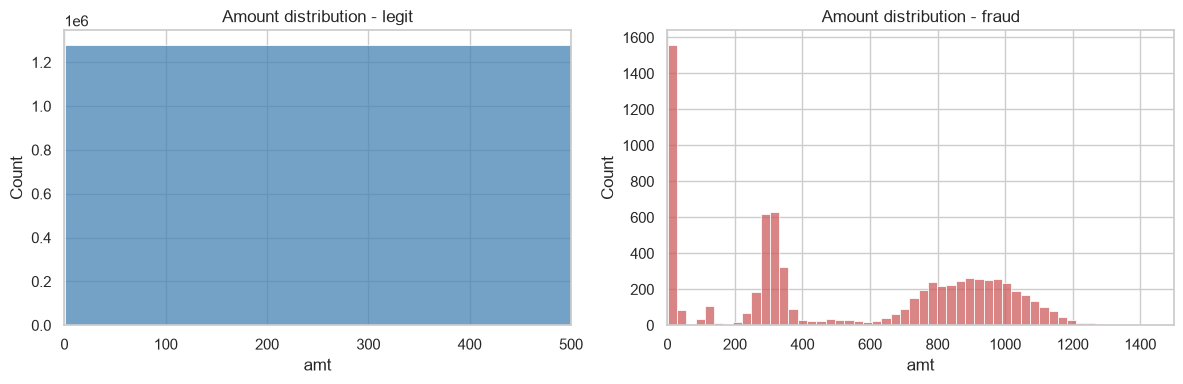

In [7]:
print(train.groupby('is_fraud')['amt'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train[train['is_fraud'] == 0]['amt'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Amount distribution - legit')
axes[0].set_xlim(0, 500)

sns.histplot(train[train['is_fraud'] == 1]['amt'], bins=50, ax=axes[1], color='indianred')
axes[1].set_title('Amount distribution - fraud')
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.show()


## 5. Time patterns

Parse `trans_date_trans_time` and look at fraud rate by hour of day
and day of week -- useful signal for the velocity features later.


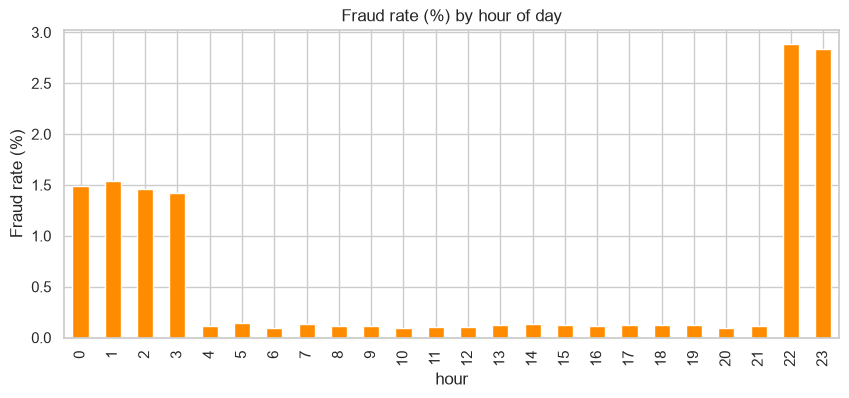

In [8]:
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
train['hour'] = train['trans_date_trans_time'].dt.hour
train['day_of_week'] = train['trans_date_trans_time'].dt.day_name()

fraud_by_hour = train.groupby('hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
fraud_by_hour.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Fraud rate (%) by hour of day')
ax.set_ylabel('Fraud rate (%)')
plt.show()


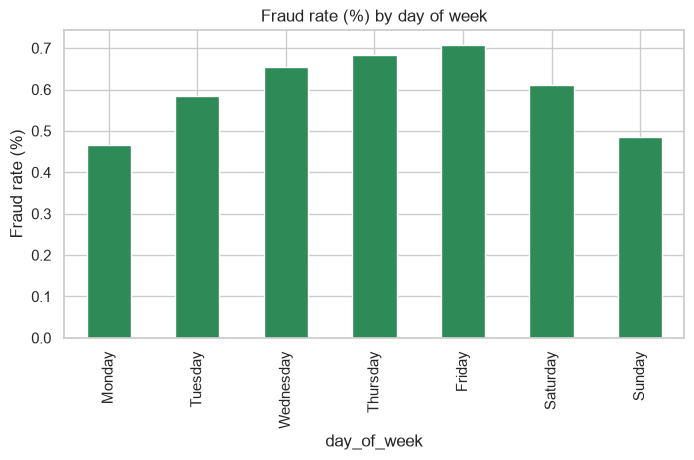

In [9]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_dow = train.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order) * 100

fig, ax = plt.subplots(figsize=(8, 4))
fraud_by_dow.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Fraud rate (%) by day of week')
ax.set_ylabel('Fraud rate (%)')
plt.show()


## 5b. Per-category amount z-score
How unusual is this amount relative to its own merchant category's typical
range -- corrects for the fact raw `amt` means something different per
category (see EDA: shopping_net vs gas_transport swing).

In [30]:
train = add_category_amt_zscore(train)
test = add_category_amt_zscore(test)

train[['category', 'amt', 'cat_avg_amt', 'cat_std_amt', 'amt_category_zscore']].head(10)

,category,amt,cat_avg_amt,cat_std_amt,amt_category_zscore
0,misc_net,4.97,80.865095,166.860495,-0.454842
1,grocery_pos,107.23,116.960986,53.214365,-0.182864
2,entertainment,220.11,64.210421,66.181129,2.355650
3,gas_transport,45.00,63.434572,15.886738,-1.160375
4,misc_pos,41.96,62.890999,134.840930,-0.155227
5,gas_transport,94.63,63.434572,15.886738,1.963614
6,grocery_net,44.54,53.670084,22.544396,-0.404982
7,gas_transport,71.65,63.434572,15.886738,0.517125
8,misc_pos,4.27,62.890999,134.840930,-0.434742
9,grocery_pos,198.39,116.960986,53.214365,1.530207


## 6. Merchant category

Some categories (e.g. online shopping, misc_net) tend to see higher fraud rates.


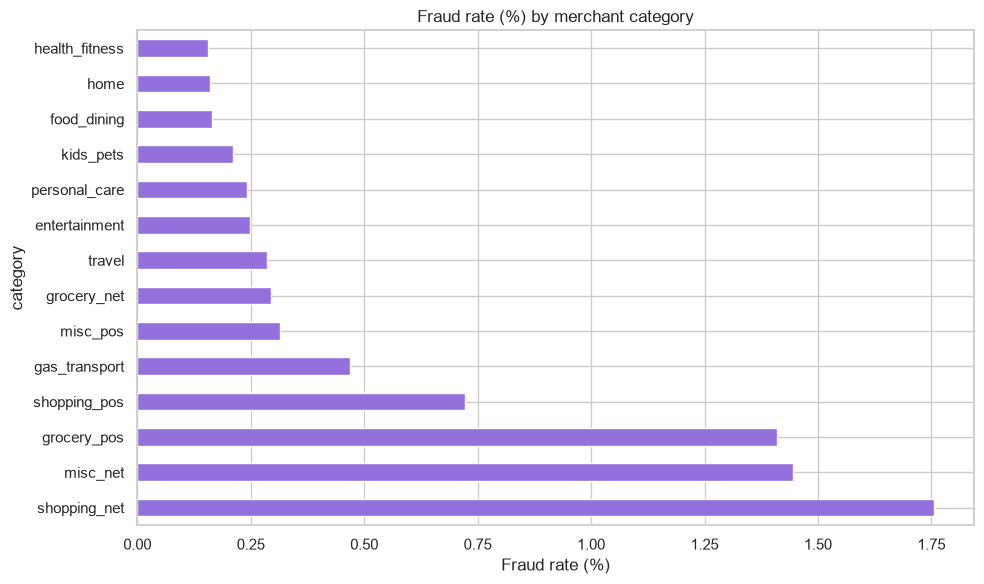

In [10]:
fraud_by_category = (train.groupby('category')['is_fraud'].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fraud_by_category.plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Fraud rate (%) by merchant category')
ax.set_xlabel('Fraud rate (%)')
plt.tight_layout()
plt.show()


## 7. Geo-distance sanity check

Preview of the merchant/cardholder distance feature that will be formalized
in `src/features/engineering.py`. Fraudulent transactions often occur
farther from the cardholder's usual location.


              count       mean        std       min        25%        50%  \
is_fraud                                                                    
0         1289169.0  76.113756  29.119051  0.022255  55.332701  78.233012   
1            7506.0  76.268330  28.752602  0.738769  55.632890  77.931954   

                75%         max  
is_fraud                         
0         98.504498  152.117173  
1         98.391090  144.522410  


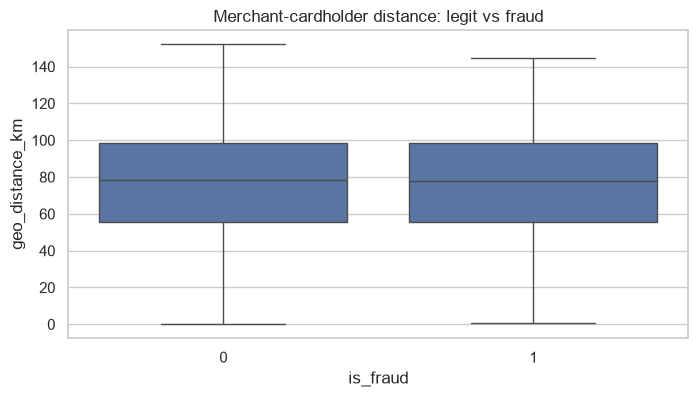

In [11]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

train['geo_distance_km'] = haversine_distance(
    train['lat'], train['long'], train['merch_lat'], train['merch_long']
)

print(train.groupby('is_fraud')['geo_distance_km'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='is_fraud', y='geo_distance_km', data=train, ax=ax, showfliers=False)
ax.set_title('Merchant-cardholder distance: legit vs fraud')
plt.show()


## 8. City population (`city_pop`)

Check whether fraud correlates with cardholder location density
(rural vs urban).


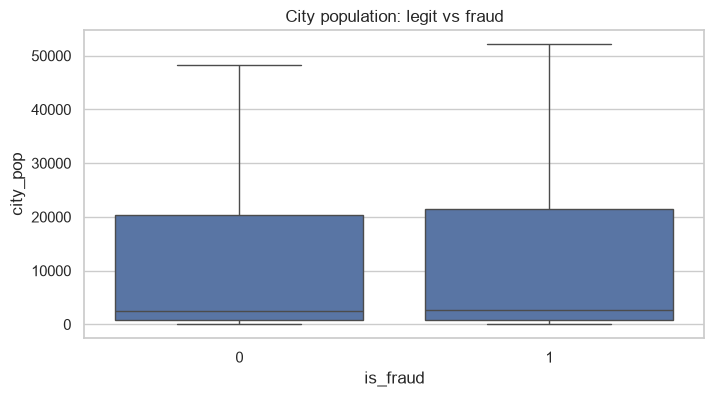

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='is_fraud', y='city_pop', data=train, ax=ax, showfliers=False)
ax.set_title('City population: legit vs fraud')
plt.show()


## 9. Correlation among numeric features


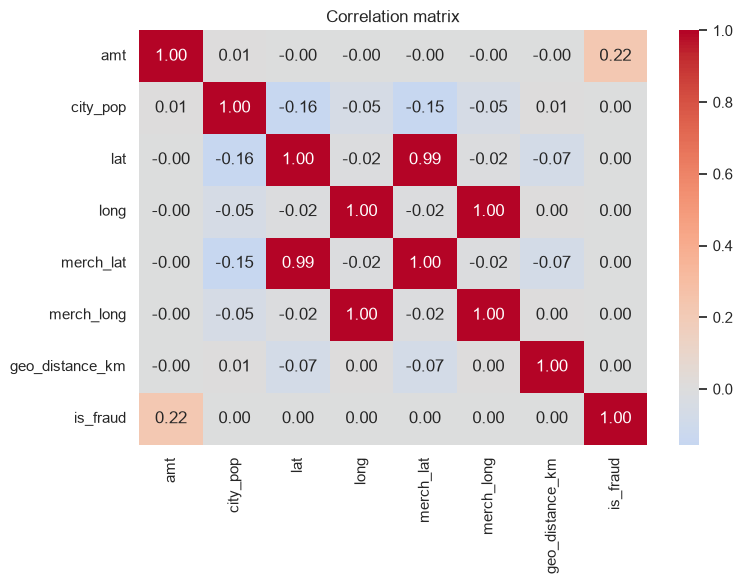

In [13]:
numeric_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long',
                'geo_distance_km', 'is_fraud']
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()


## 10. Key takeaways

Fill in after running against the real data, e.g.:

- Class imbalance ratio: legit vs fraud (~X% fraud)
- Fraud skews toward [amount range / time of day / category]
- `geo_distance_km` shows [stronger / weaker] separation than expected -- 
  informs whether it's a high-value feature for the supervised models
- No / some missing values requiring [imputation strategy]

**Next notebook:** `02_feature_engineering.ipynb` -- formalize velocity,
geo-distance, and spending-profile features, then push to SageMaker Feature Store.


In [14]:
print(f"Train fraud rate: {train['is_fraud'].mean()*100:.4f}%")
print(f"Test fraud rate:  {test['is_fraud'].mean()*100:.4f}%")

Train fraud rate: 0.5789%
Test fraud rate:  0.3860%


In [15]:
print("Train date range:", train['trans_date_trans_time'].min(), "to", train['trans_date_trans_time'].max())
print("Test date range:", test['trans_date_trans_time'].min(), "to", test['trans_date_trans_time'].max())

Train date range: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Test date range: 2020-06-21 12:14:25 to 2020-12-31 23:59:34


<Axes: title={'center': 'Monthly fraud rate (%) - train'}, xlabel='month'>

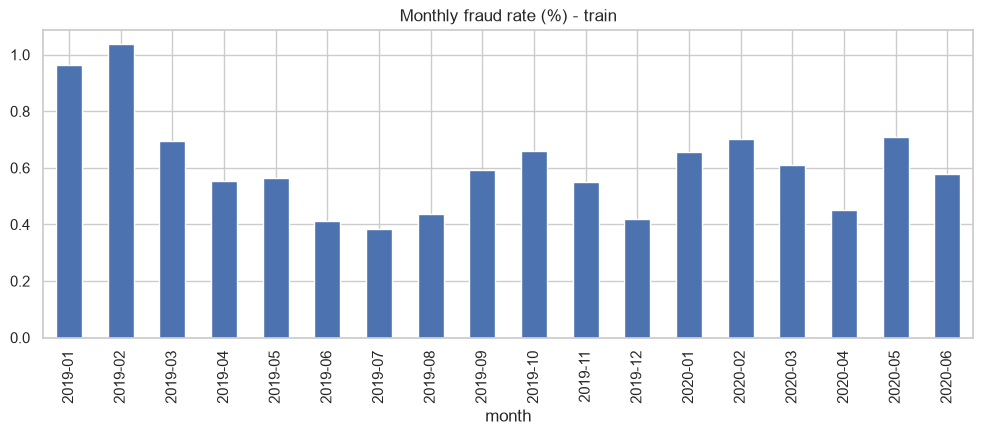

In [16]:
train['month'] = train['trans_date_trans_time'].dt.to_period('M')
monthly_fraud_rate = train.groupby('month')['is_fraud'].mean() * 100
monthly_fraud_rate.plot(kind='bar', figsize=(12, 4), title='Monthly fraud rate (%) - train')